In [1]:
from typing import Annotated
from typing_extensions import TypedDict
# from langchain_openai import ChatOpenAI
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage

import os
from dotenv import load_dotenv
load_dotenv() # to load env variables from .env file

True

In [2]:
load_dotenv() 
import os
os.environ["GROQ_API_KEY"] = os.getenv('GROQ_API_KEY')
os.environ["LANGSMITH_API_KEY"]=os.getenv('LANGSMITH_API_KEY')

os.environ["LANGSMITH_TRACING"]="true"  # from langchain docs and true is not booloean


In [3]:
os.environ["LANGSMITH_PROJECT"]="Test_Project"

In [4]:
from langchain.chat_models import init_chat_model
llm=init_chat_model('groq:llama-3.1-8b-instant')
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000188E47F75C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000188E4924560>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [ ]:
## state graph with tool call
from langchain_core.tools import tool

@tool
def add(a:float, b:float) -> float:
    """Add two numbers together."""
    return a + b

tools=[add]
tool_node = ToolNode([add])

llm_with_tool=llm.bind_tools([add])

def call_llm_model(state:State) -> State:
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


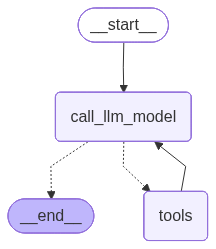

In [7]:
# Creating a state graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
# from langgraph.checkpoint.memory import MemorySaver

# memory=MemorySaver()
# 

# Node Defination
def call_llm_model(state:State) -> State:
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## graph
builder=StateGraph(State)
builder.add_node("call_llm_model",call_llm_model)
builder.add_node("tools", ToolNode(tools))

# adding edges
builder.add_edge(START, "call_llm_model")
builder.add_conditional_edges("call_llm_model",
                              # if the latest message in the messages list contains a tool call, then go to the tools node
                              # if the latest message in the messages list does not contain a tool call, then go to the end node
                               tools_condition)
builder.add_edge("tools", "call_llm_model")      

graph=builder.compile()              
from IPython.display import Image,  display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
response=graph.invoke({"messages":"What is recent ai news"})


In [9]:
response

{'messages': [HumanMessage(content='What is recent ai news', additional_kwargs={}, response_metadata={}, id='deb2d29d-36be-4d2f-bf8d-445733f7e048'),
  AIMessage(content='brave_search={"query": "recent ai news"}', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 219, 'total_tokens': 231, 'completion_time': 0.02219073, 'completion_tokens_details': None, 'prompt_time': 0.019320366, 'prompt_tokens_details': None, 'queue_time': 0.052993344, 'total_time': 0.041511096}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dba29-0673-7152-ae6f-c13adbd5637f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 219, 'output_tokens': 12, 'total_tokens': 231})]}

In [10]:
response=graph.invoke({"messages":"What is 5 plus 2"})


In [11]:
response

{'messages': [HumanMessage(content='What is 5 plus 2', additional_kwargs={}, response_metadata={}, id='d7ec7958-6074-4bed-8219-26d6a96c42ac'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'amtp223y6', 'function': {'arguments': '{"a":5,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 221, 'total_tokens': 239, 'completion_time': 0.03807839, 'completion_tokens_details': None, 'prompt_time': 0.024066041, 'prompt_tokens_details': None, 'queue_time': 0.208625669, 'total_time': 0.062144431}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dba29-083c-7d21-ae41-79e42e4c6253-0', tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 2}, 'id': 'amtp223y6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 18, 't

In [12]:
response=graph.invoke({"messages":"What is 5 plus 20?"})
